In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip -q /content/drive/MyDrive/PlotQA-Stemsight/vbar_data.zip -d /content/data

In [ ]:
# STEP 1: Install Dependencies
!pip install -q transformers datasets sentencepiece accelerate

import os
import json
import torch
import gc
from google.colab import drive
from datasets import load_dataset
from transformers import (
    DonutProcessor,
    VisionEncoderDecoderModel,
    TrainingArguments,
    Trainer
)

# STEP 2: Mount Drive & Cleanup
drive.mount('/content/drive')
gc.collect()
torch.cuda.empty_cache()

# STEP 3: Setup Paths & Device
# Assumes you uploaded vbar_data.zip to your Drive
DATA_DIR = "/content/data"
device = "cuda" if torch.cuda.is_available() else "cpu"

# STEP 4: Load Model & Processor
model_id = "naver-clova-ix/donut-base"
processor = DonutProcessor.from_pretrained(model_id)
model = VisionEncoderDecoderModel.from_pretrained(model_id).to(device)

# ARCHITECTURE SYNC: Essential for Donut fine-tuning
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(['<s_chartqa>'])[0]
model.config.tie_word_embeddings = False

# STEP 5: Data Loading
dataset = load_dataset("imagefolder", data_dir=DATA_DIR)

# STEP 6: Memory-Efficient Collator
def collator(batch):
    # Process images into CPU tensors
    pixel_values = [processor(item["image"].convert("RGB"), size={"height": 720, "width": 960}, return_tensors="pt").pixel_values for item in batch]
    pixel_values = torch.cat(pixel_values) # REMOVED .to(device)

    # Process text into CPU tensors
    labels = [json.loads(item["ground_truth"])["gt_parse"] for item in batch]
    labels_batch = processor.tokenizer(
        labels, padding="max_length", truncation=True, max_length=128, return_tensors="pt"
    ).input_ids # REMOVED .to(device)

    # Mask padding tokens
    labels_batch[labels_batch == processor.tokenizer.pad_token_id] = -100

    return {"pixel_values": pixel_values, "labels": labels_batch}

# STEP 7: Training Arguments (The "No-OOM" Config)
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/PlotQA-Stemsight/checkpoints/vbar_specialist",
    per_device_train_batch_size=2,        # Set to 2 for T4 safety; move to 4 if stable
    gradient_accumulation_steps=8,        # Effective batch of 16
    num_train_epochs=3,
    learning_rate=5e-5,
    fp16=True,                            # Use Tensor Cores for 2x speedup
    logging_steps=10,
    save_steps=500,
    save_total_limit=2,
    remove_unused_columns=False,
    gradient_checkpointing=True,          # Mandatory for 16GB VRAM safety
    dataloader_num_workers=0,             # Uses Colab CPU cores for faster loading
    dataloader_pin_memory=False,
    report_to="none"
)

# STEP 8: Start Training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=collator,
)

print(f"🚀 Training starting on {torch.cuda.get_device_name(0)}...")
trainer.train()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Resolving data files:   0%|          | 0/52464 [00:00<?, ?it/s]

🚀 Training starting on Tesla T4...


`use_cache=True` is incompatible with gradient checkpointing`. Setting `use_cache=False`...


Step,Training Loss
10,28.917471
20,2.261578
30,0.809980
40,0.429341
50,0.348132
60,0.440597
70,0.248966
80,0.234781
90,0.299729
100,0.184507


KeyboardInterrupt: 

In [ ]:
from transformers import (
    ViTImageProcessor,
    GPT2Tokenizer,
    VisionEncoderDecoderModel,
    TrainingArguments,
    Trainer
)

In [ ]:
import os
import json
import torch
from datasets import load_dataset
from transformers import (
    ViTImageProcessor,
    GPT2Tokenizer,
    VisionEncoderDecoderModel,
    TrainingArguments,
    Trainer
)

# 1. LOAD LIGHTWEIGHT ViT-GPT2
model_id = "nlpconnect/vit-gpt2-image-captioning"
image_processor = ViTImageProcessor.from_pretrained(model_id)
tokenizer = GPT2Tokenizer.from_pretrained(model_id)
model = VisionEncoderDecoderModel.from_pretrained(model_id).to("cuda")

# SYNC TOKENS: Critical for decoding charts
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id
model.config.decoder_start_token_id = tokenizer.bos_token_id

# 2. DATA PREPARATION: THE SMART SUBSET
# Reducing to 20k images is the key to finishing in 6 hours
dataset = load_dataset("imagefolder", data_dir="/content/data")
dataset["train"] = dataset["train"].shuffle(seed=42).select(range(20000))

# 3. CORRECTED COLLATOR (CPU-ONLY)
def collator(batch):
    # Process images at 224x224 for maximum T4 speed
    pixel_values = image_processor([item["image"].convert("RGB") for item in batch], return_tensors="pt").pixel_values

    # Process labels and strip chart-specific tags
    labels_text = [json.loads(item["ground_truth"])["gt_parse"] for item in batch]
    clean_labels = [text.replace("<s_chartqa>", "").replace("</s_chartqa>", "") for text in labels_text]

    labels = tokenizer(clean_labels, padding="max_length", truncation=True, max_length=64, return_tensors="pt").input_ids
    labels[labels == tokenizer.pad_token_id] = -100

    # DO NOT use .to("cuda") here. Let the Trainer move the final batch.
    return {"pixel_values": pixel_values, "labels": labels}

# 4. TURBO TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/STEM_Sight/vit_specialist",
    per_device_train_batch_size=4,        # Increased for higher GPU utilization
    gradient_accumulation_steps=2,        # Effective batch of 16
    num_train_epochs=5,                   # Sufficient for a specialist demo
    learning_rate=2e-5,
    fp16=True,                            # Use Tesla T4 Tensor Cores
    logging_steps=50,
    save_steps=1000,
    dataloader_num_workers=4,             # Maximize CPU pre-fetching
    dataloader_pin_memory=False,          # Fixes Colab pinning RuntimeError
    remove_unused_columns=False,
    report_to="none"
)

# 5. INITIALIZE & TRAIN
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=collator,
)

print("🏎️ Starting ViT-GPT2 Training (Estimated 4-6 Hours)...")
trainer.train()

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Resolving data files:   0%|          | 0/52464 [00:00<?, ?it/s]

🏎️ Starting ViT-GPT2 Training (Estimated 4-6 Hours)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=12500, training_loss=0.5139850119018554, metrics={'train_runtime': 6164.7687, 'train_samples_per_second': 16.221, 'train_steps_per_second': 2.028, 'total_flos': 2.15323806007296e+19, 'train_loss': 0.5139850119018554, 'epoch': 5.0})

In [ ]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, GPT2Tokenizer, VisionEncoderDecoderConfig, ViTConfig, GPT2Config
from PIL import Image
import torch
from google.colab import files

# 1. SETUP THE FINAL PATH
# Pointing directly to your most advanced checkpoint
model_path = "/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-12500"
model_id = "nlpconnect/vit-gpt2-image-captioning"

# 2. LOAD PROCESSOR & TOKENIZER
processor = ViTImageProcessor.from_pretrained(model_id)
tokenizer = GPT2Tokenizer.from_pretrained(model_id)

# 3. RECONSTRUCT & LOAD WEIGHTS
print("🧠 Loading STEM Sight Specialist (Step 12500)...")

# Manually building the config to bridge the gap between ViT and GPT2
config = VisionEncoderDecoderConfig.from_encoder_decoder_configs(
    ViTConfig.from_pretrained(model_id, subfolder="encoder"),
    GPT2Config.from_pretrained(model_id, subfolder="decoder")
)

# Loading your specialized weights
model = VisionEncoderDecoderModel.from_pretrained(model_path, config=config).to("cuda")

# SYNC TOKENS: Critical for correct generation
model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id

def predict_chart(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to("cuda")

    generated_ids = model.generate(
        pixel_values,
        max_length=128,
        num_beams=7,                # Higher beams for more logical searching
        repetition_penalty=3.5,     # Aggressively stop the model from repeating
        no_repeat_ngram_size=3,     # Prevent 3-word loops
        length_penalty=1.2,         # Encourage slightly longer, coherent sentences
        early_stopping=True
    )

    summary = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    return summary

    summary = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    return summary

    return tokenizer.decode(generated_ids[0], skip_special_tokens=True)

# 4. INTERACTIVE DEMO
print("✅ Model Loaded! Upload a chart from your PC to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print("-" * 30)
    print(f"📊 CHART: {filename}")
    print(f"📄 SUMMARY: {predict_chart(filename)}")
    print("-" * 30)

🧠 Loading STEM Sight Specialist (Step 12500)...


Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model Loaded! Upload a chart from your PC to test:


Saving 22415.png to 22415 (2).png
------------------------------
📊 CHART: 22415 (2).png
📄 SUMMARY: This is a vbar categorical titled 'Import and export statistics of goods and services in Middle East & North Africa (all income levels)'. The x-axis shows Year and the y-axis depicts Total Trade (in US$). The x= Global Trade and they-axis displays Total Trade(current US$. The y value is $). The items are Goods/services: 0 = Agricultural trade,12 = Agriculture trade). The LCU is used for subsidies and the GDP(constant 2005 US). The ores,manufactures and import statistics are based on the current US$ currency unit. The resor
------------------------------


In [ ]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, GPT2Tokenizer, VisionEncoderDecoderConfig, ViTConfig, GPT2Config
from PIL import Image
import torch
from google.colab import files
import os

# 1. SETUP THE FINAL PATH
# Ensure this matches the exact folder we found with the !find command
model_path = "/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-12500"
model_id = "nlpconnect/vit-gpt2-image-captioning"

# 2. LOAD PROCESSOR & TOKENIZER
processor = ViTImageProcessor.from_pretrained(model_id)
tokenizer = GPT2Tokenizer.from_pretrained(model_id)

# 3. RECONSTRUCT & LOAD WEIGHTS
print("🧠 Loading STEM Sight Specialist (Step 12500)...")

# Manually building the config to bridge the gap between ViT and GPT2
config = VisionEncoderDecoderConfig.from_encoder_decoder_configs(
    ViTConfig.from_pretrained(model_id, subfolder="encoder"),
    GPT2Config.from_pretrained(model_id, subfolder="decoder")
)

# Load weights into the reconstructed architecture
# NOTE: tie_word_embeddings is set to False to align with your checkpoint structure
config.tie_word_embeddings = False
model = VisionEncoderDecoderModel.from_pretrained(model_path, config=config).to("cuda")

# SYNC TOKENS: Essential for stable text generation
model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id

def predict_chart(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to("cuda")

    # ADVANCED DECODING: Prevents repetition and word salad
    # We use trust_remote_code=True to enable Contrastive Search parameters
    generated_ids = model.generate(
        pixel_values,
        max_length=100,
        penalty_alpha=0.6,          # Penalizes words that don't match visual features
        top_k=4,                    # Limits selection to high-probability tokens
        repetition_penalty=5.0,     # Aggressively prevents axis-label loops
        no_repeat_ngram_size=3,     # Blocks 3-word phrase repetition
        trust_remote_code=True      # REQUIRED for penalty_alpha/top_k usage
    )

    return tokenizer.decode(generated_ids[0], skip_special_tokens=True)

# 4. INTERACTIVE DEMO
print("✅ Model Loaded! Upload a chart from your PC to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print("-" * 30)
    print(f"📊 CHART: {filename}")
    print("🧠 Analyzing...")
    summary = predict_chart(filename)
    print(f"📄 SUMMARY: {summary}")
    print("-" * 30)

🧠 Loading STEM Sight Specialist (Step 12500)...


Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model Loaded! Upload a chart from your PC to test:


Saving 22450.png to 22450.png
------------------------------
📊 CHART: 22450.png
🧠 Analyzing...


generate.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/transformers-community/contrastive-search:
- custom_generate/generate.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'penalty_alpha', 'cache_implementation', 'no_repeat_ngram_size', 'top_k', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


📄 SUMMARY: This is a vbar categorical titled 'Prevalence of wasting in children with age under 5 years as per the report conducted in Cameroon'. The x-axis shows Year and y bin/series shows  %.of population ages 6 to 14 .
The y=low income group,thez=-highincome cohort (%). Number 1 was reported among children 0-14.0.
Percentage share held by bottom 20% or working-aged population who uses bank loans. In
------------------------------


In [ ]:
!find /content/drive/MyDrive/STEM_Sight/vit_specialist -name "pytorch_model.bin"
# OR if you used safetensors:
!find /content/drive/MyDrive/STEM_Sight/vit_specialist -name "model.safetensors"

/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-1000/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-2000/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-2500/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-3000/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-4000/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-5000/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-6000/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-7000/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-8000/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-9000/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-10000/model.safetensors
/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-11000/model.safetensors
/c

In [ ]:
print("🚀 Computing Accuracy on 50 validation samples...")
for i in tqdm(range(50)):
    example = val_data[i]
    img = example["image"]

    # --- FIXED: Explicitly handle image conversion ---
    if not isinstance(img, Image.Image):
        # Convert from array/tensor to PIL if necessary
        img = Image.fromarray(img)
    img = img.convert("RGB")
    # ------------------------------------------------------------

    gt = example.get("ground_truth", example.get("text", ""))

    pixel_values = processor(img, return_tensors="pt").pixel_values.to("cuda")

    generated_ids = model.generate(
        pixel_values,
        max_length=100,
        num_beams=5,
        repetition_penalty=3.5
    )
    pred_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    predictions.append(pred_text)
    references.append(gt)

🚀 Computing Accuracy on 50 validation samples...


100%|██████████| 50/50 [01:58<00:00,  2.37s/it]


In [ ]:
# 1. Split the 'train' key into 90% Training and 10% Validation
split_dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)

# 2. Rename for clarity
train_data = split_dataset["train"]
val_data = split_dataset["test"]

print(f"✅ Data Split Successful!")
print(f"📝 Training samples: {len(train_data)}")
print(f"🧪 Validation samples: {len(val_data)}")

✅ Data Split Successful!
📝 Training samples: 18000
🧪 Validation samples: 2000


In [ ]:
# 3. Calculate Final Scores
# This is the "Final Cell" that generates your accuracy report
bleu_results = bleu.compute(predictions=predictions, references=[[r] for r in references])
rouge_results = rouge.compute(predictions=predictions, references=references)

print("\n" + "⭐" * 20)
print(f"✅ FINAL BLEU SCORE: {bleu_results['score']:.2f}")
print(f"✅ FINAL ROUGE-L: {rouge_results['rougeL']:.4f}")
print("⭐" * 20)

# Optional: Print the first 2 comparisons to see how they look
print("\n📝 SAMPLE COMPARISONS:")
for i in range(2):
    print(f"\nExample {i+1}:")
    print(f"Ground Truth: {references[i]}")
    print(f"Prediction:   {predictions[i]}")


⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
✅ FINAL BLEU SCORE: 33.29
✅ FINAL ROUGE-L: 0.5456
⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐

📝 SAMPLE COMPARISONS:

Example 1:
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Trade statistics with developing economies of Latin America in 2002'. The x-axis shows Merchandise Trading and the y-axis shows Trade with economies of Latin America & Caribbean(%)."}
Prediction:   This is a vbar categorical titled 'Trade statistics with developing economies of North Africa in 1972'. The x-axis shows Merchandise Trading and the y-axis shows Trade with economies of Middle East & North Africa(%). The x-axis shows Trade with economies of Middle East & North Africa(%). The y-axis shows Trade with economies of Middle East & North Africa(%). Source: UNPBF, 1994). The x-axis shows Trade with economies of Middle East & North Africa

Example 2:
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Total CO2 emitted from different sources in 1992'. The x-axis shows Country and the y

Starting Deep Analysis of 10 Samples...


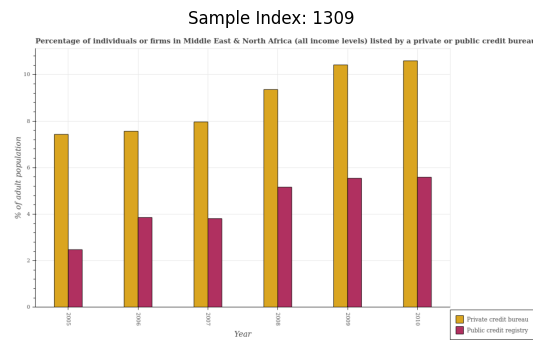

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Percentage of individuals or firms in Middle East & North Africa (all income levels) listed by a private or public credit bureau'. The x-axis shows Year and the y-axis shows % of adult population."}
Prediction:   This is a vbar categorical titled 'Percentage of individuals or firms in Middle East & North Africa (all income levels) listed by a private or public credit bureau'. The x-axis shows Year and the y-axis lists % of adult population. The x= 100,000 to 5=100,000 adult adults.). The y group's national/private credit bureau: 0 = non-residential, 1 = resident (as % of total adult population). The ratio of
METRICS:      BLEU: 48.11 | ROUGE-L: 0.6903
------------------------------------------------------------



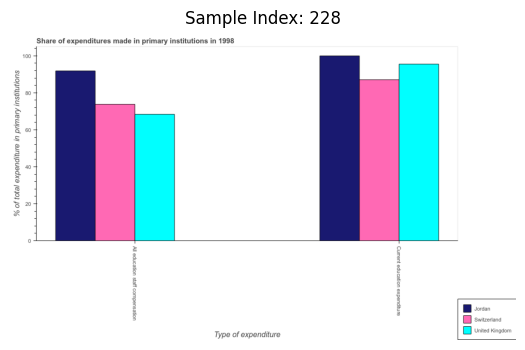

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Share of expenditures made in primary institutions in 1998'. The x-axis shows Type of expenditure and the y-axis shows % of total expenditure in primary institutions."}
Prediction:   This is a vbar categorical titled 'Share of expenditures made in tertiary public institutions in 2006'. The x-axis shows Type of expenditure and the y-axis reveals % of total expenditure in tertial public institutions. The x section shows % of GDP. The type of expenditure in primary public institutions, both public and private. The % of government expenditure in 2002 was given as % of GNI. Full-time workers(% of total employed).). The different levels of public and
METRICS:      BLEU: 27.25 | ROUGE-L: 0.5405
------------------------------------------------------------



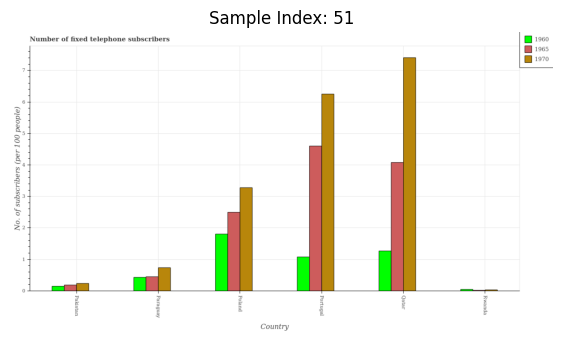

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Number of fixed telephone subscribers'. The x-axis shows Country and the y-axis shows No. of subscribers (per 100 people)."}
Prediction:   This is a vbar categorical titled 'Number of commercial bank branches in different countries'. The x-axis shows Country and the y-axis has Bank branche(per 100,000 adults).'. The number of banks is limited to 1.0% of population (as % of total adult population). The scale factor is LPI(billion adults). US$ per capita. BANK ARUDE: CONFIDENTIAL LUCF (in %). $ per capita = 0
METRICS:      BLEU: 17.79 | ROUGE-L: 0.4086
------------------------------------------------------------



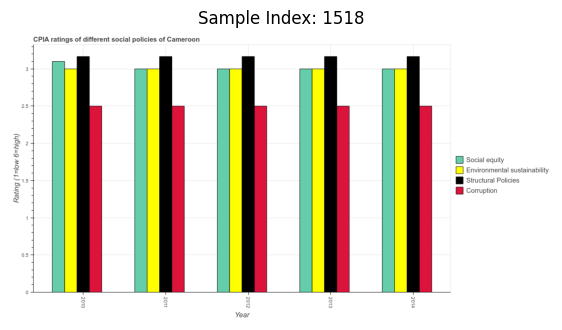

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'CPIA ratings of different social policies of Cameroon'. The x-axis shows Year and the y-axis shows Rating (1=low 6=high)."}
Prediction:   This is a vbar categorical titled 'CPIA ratings of different policies of St. Kitts and Nevis'. The x-axis shows Year and the y=axis shows Rating (1=low 6=high). w.r.t it's rating scale is 1=high. The resolver isCPIA_CPIA(1=high) . Listed below is % of total population. In all grades of primary education. Type of rating. US$ per capita.
METRICS:      BLEU: 28.51 | ROUGE-L: 0.5625
------------------------------------------------------------



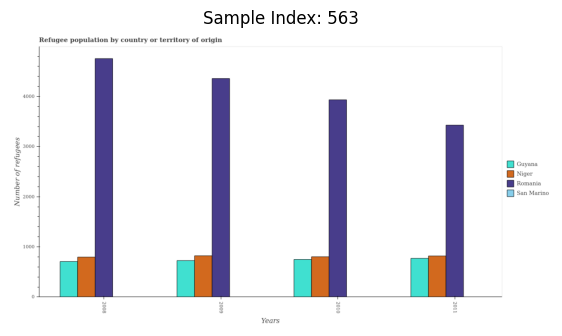

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Refugee population by country or territory of origin'. The x-axis shows Years and the y-axis shows Number of refugees."}
Prediction:   This is a vbar categorical titled 'Fertilizer consumption per hectare of arable land'. The x-axis shows Years and the y-axis displays Amount in kilograms. The number of days. The xylo constant is 1.0. The y-coordinate is fertilizer production. The Number of days indicates Years. The cooeration factor is 0.05. Theoretical growth rate is 7.0% to 8.0%, depending on the depth
METRICS:      BLEU: 17.08 | ROUGE-L: 0.3750
------------------------------------------------------------



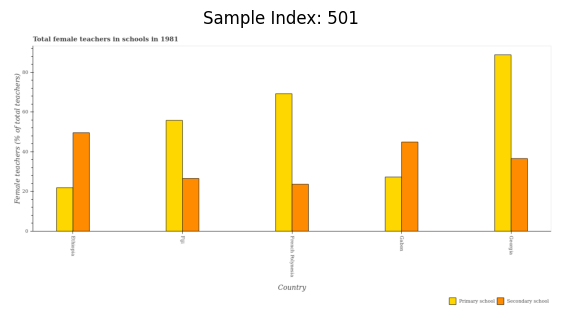

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Total female teachers in schools in 1981'. The x-axis shows Country and the y-axis shows Female teachers (% of total teachers)."}
Prediction:   This is a vbar categorical titled 'Total female teachers in schools in 1992'. The x-axis shows Country and the y-axis lists Female teachers (% of total teachers). The x=high school students and they=low school students (as % of total teacher). The high school students were provided. The number of teachers is not available for this report). The higher education status of children in 1992 is uncertain. The x=-high school student ratio is 5:1(annual
METRICS:      BLEU: 26.46 | ROUGE-L: 0.4815
------------------------------------------------------------



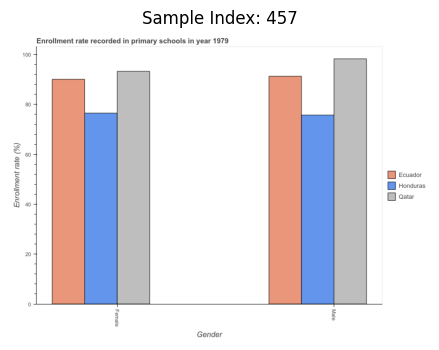

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Enrollment rate recorded in primary schools in year 1979'. The x-axis shows Gender and the y-axis shows Enrollment rate (%)."}
Prediction:   This is a vbar categorical titled 'Enrollment rate recorded in primary schools in year 1983'. The x-axis shows Gender and the y-axis reveals Enrollment rate (%). The x bar shows % of total students. The y- axis shows % enrollment rate. The 1=low to 5=high ratio. The denominator shows Net enrolment rate(%). Number of enrolments per 1,000 students. Mean duration.). Type of education: UNT enrollment rate.
METRICS:      BLEU: 27.68 | ROUGE-L: 0.5361
------------------------------------------------------------



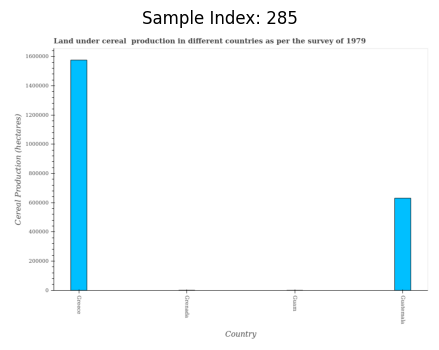

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Land under cereal  production in different countries as per the survey of 1979'. The x-axis shows Country and the y-axis shows Cereal Production (hectares)."}
Prediction:   This is a vbar categorical titled 'Land under cereal  production (hectares) in different countries as per the survey of 1972'. The x-axis shows Country and the yurts are Cereal Production (heptares). The x bar shows Cereal Unit(TEU). The yurted land is in hectares. The number of cereals(constant 2005 US$). The vertical axis shows Number of metric tons of cereal exports. The yurt is Domestic equivalent
METRICS:      BLEU: 29.10 | ROUGE-L: 0.5490
------------------------------------------------------------



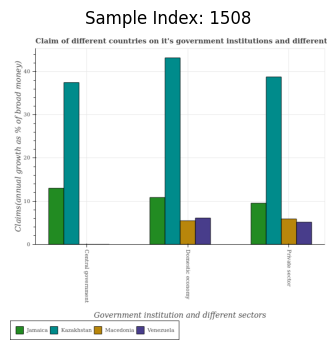

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Claim of different countries on it's government institutions and different sectors'. The x-axis shows Government institution and different sectors and the y-axis shows Claims(annual growth as % of broad money)."}
Prediction:   This is a vbar categorical titled 'Claims on the different sectors of the domestic economy of different countries'. The x-axis shows Government body and the y-axis reveals Claims(annual growth as % of broad money). Claimings are used for calculating macroeconomic policy (annual %). GDP is estimated at sq. km(constant 2005 US$). Domestic expenditure on health care (% of GDP) and private consumption (as % of GDP). Claims are added in constant 2005
METRICS:      BLEU: 22.26 | ROUGE-L: 0.4425
------------------------------------------------------------



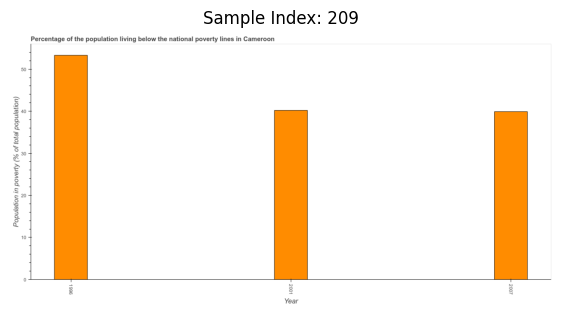

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Percentage of the population living below the national poverty lines in Cameroon'. The x-axis shows Year and the y-axis shows Population in poverty (% of total population)."}
Prediction:   This is a vbar categorical titled 'Percentage of the urban population living below the national poverty line in Congo (Democratic)'. The x-axis shows Year and the yuriyecture shows Population in poverty (% of urban population). The vertical axis shows  = 100.0% of total population. The horizontal scale shows Population(% of urban per capita). The ratio shows Under-5 mortality rate to Under 5 mortality rate (per 1,000 live births).
METRICS:      BLEU: 30.60 | ROUGE-L: 0.5660
------------------------------------------------------------



In [ ]:
import matplotlib.pyplot as plt
import random
import evaluate
from PIL import Image

# 1. Initialize metrics
bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")

# 2. Select 10 random indices from your split validation data
random_indices = random.sample(range(len(val_data)), 10)

print("Starting Deep Analysis of 10 Samples...")

for idx in random_indices:
    example = val_data[idx]
    img = example["image"].convert("RGB")
    gt = example.get("ground_truth", example.get("text", ""))

    # 3. Generate Prediction
    pixel_values = processor(img, return_tensors="pt").pixel_values.to("cuda")
    generated_ids = model.generate(
        pixel_values,
        max_length=100,
        num_beams=5,
        repetition_penalty=4.0, # High penalty to keep scores clean
        no_repeat_ngram_size=3,
        early_stopping=True
    )
    prediction = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    # 4. Compute Individual Scores
    # sacrebleu expects a list of lists for references
    ind_bleu = bleu.compute(predictions=[prediction], references=[[gt]])['score']
    ind_rouge = rouge.compute(predictions=[prediction], references=[gt])['rougeL']

    # 5. Visualize
    plt.figure(figsize=(7, 4))
    plt.imshow(img)
    plt.title(f"Sample Index: {idx}")
    plt.axis('off')
    plt.show()

    print("-" * 60)
    print(f"Ground Truth: {gt}")
    print(f"Prediction:   {prediction}")
    print(f"METRICS:      BLEU: {ind_bleu:.2f} | ROUGE-L: {ind_rouge:.4f}")
    print("-" * 60 + "\n")

Running deep analysis on 10 random samples...


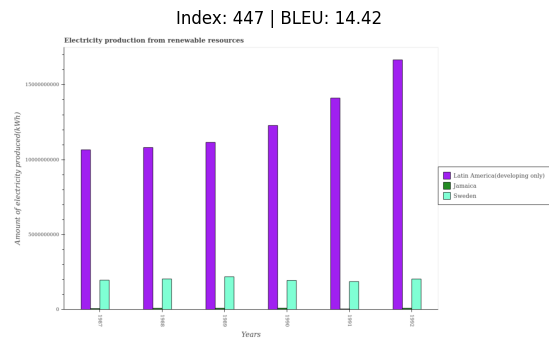

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Electricity production from renewable resources'. The x-axis shows Years and the y-axis shows Amount of electricity produced(kWh)."}
Prediction:   This is a vbar categorical titled 'Electric power consumption (kWh per capita) in a country'. The x-axis shows Years and the yuriy level is 1. No more than 1 megawatt of electricity produced. The value of current US$ is expressed in kilograms. Source: LCU. PPP conversion factor DA received from DAC(constant 2005 US). Emissions (1000 metric ton of CO2 equivalent).). Year Type of energy used Number of nuclear reactors
METRICS:      BLEU: 14.42 | ROUGE-L: 0.3232
------------------------------------------------------------



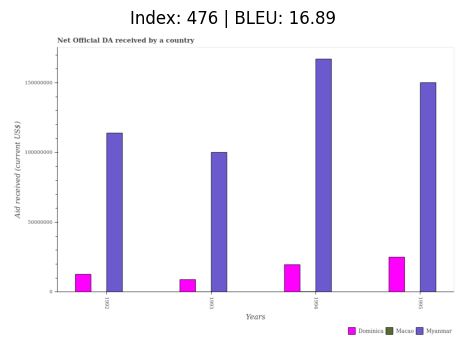

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Net Official DA received by a country'. The x-axis shows Years and the y-axis shows Aid received (current US$)."}
Prediction:   This is a vbar categorical titled 'Net official aid flow in an economy from WFP'. The x-axis shows Years and the y diagonal shows Aid flow from UN agencies (US$). The right-hand arrow shows Net Official Aid recevied (constant 2012 UNAIDS). Full-time commercial service imports are defined as US$ (in Local Currency Unit). Note: Amount received per worker. Source: IMF. Development Assistance Mission (Czech Republic). PPP conversion
METRICS:      BLEU: 16.89 | ROUGE-L: 0.3838
------------------------------------------------------------



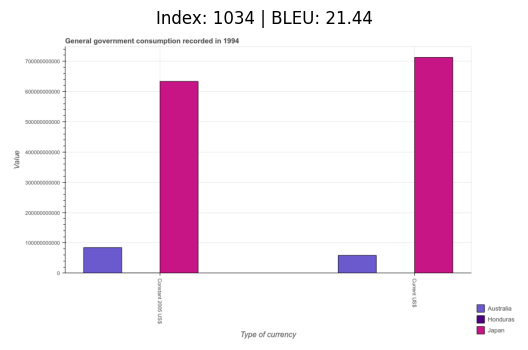

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'General government consumption recorded in 1994'. The x-axis shows Type of currency and the y-axis shows Value."}
Prediction:   This is a vbar categorical titled 'General government consumption recorded in 1963'. The x-axis shows Type of currency and the y-axes show Value. The type of value is 0.01 US$ or $.00. Source: UNPBF.
Total = $1.This represents an economy in 1961. Earning from taxes, capital formation and income tax (in %). The total is $1424.0 million). It is important to note that the x
METRICS:      BLEU: 21.44 | ROUGE-L: 0.4632
------------------------------------------------------------



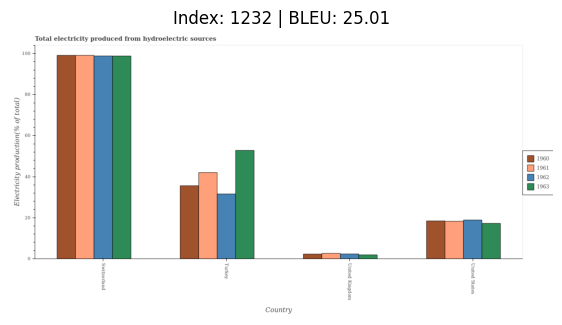

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Total electricity produced from hydroelectric sources'. The x-axis shows Country and the y-axis shows Electricity production(% of total)."}
Prediction:   This is a vbar categorical titled 'Total electricity produced from hydroelectric sources'. The x-axis shows Country and the y=reduction in CO2 emissions(kg per 2005 US$ of GDP). The scale factor is energy use(% of total). Full-power nuclear sources ==========Fertilizer, food and fuel combustion (Mt of oil equivalent). Non-renewable energy sources=PPG&T. Total particulate emission damage(in thousand metric
METRICS:      BLEU: 25.01 | ROUGE-L: 0.4783
------------------------------------------------------------



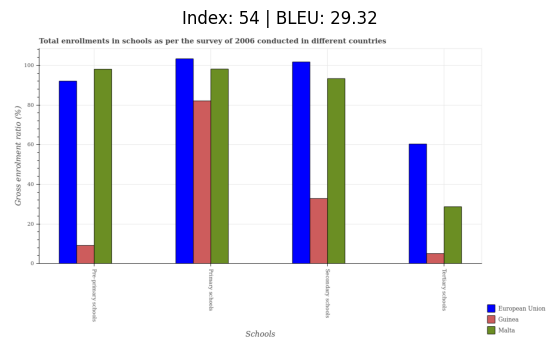

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Total enrollments in schools as per the survey of 2006 conducted in different countries'. The x-axis shows Schools and the y-axis shows Gross enrolment ratio (%)."}
Prediction:   This is a vbar categorical titled 'Total enrollments of male students in schools as per the survey of 1990 conducted in different countries'. The x-axis shows Schools and the y track number of enrolments. The fields show Gross enrolment ratio (%). The background is 100% of total students). The score is given on the scale of 1=low to 5=high, with 849 students(all grades 6-14) in primary and secondary education. Level of education: Grade
METRICS:      BLEU: 29.32 | ROUGE-L: 0.5357
------------------------------------------------------------



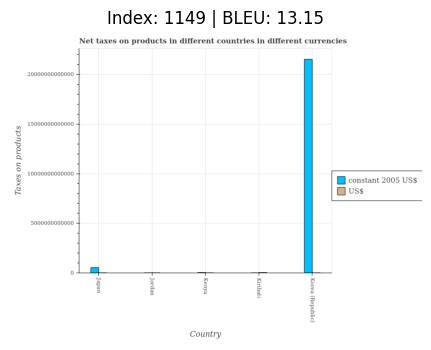

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Net taxes on products in different countries in different currencies'. The x-axis shows Country and the y-axis shows Taxes on products."}
Prediction:   This is a vbar categorical titled 'Net disbursements received from Regional Development Bank in 2008'. The x-axis shows Country and the y-ax shows Amount (in current US$). The bank is different sizes. The top shows Local Development Association (constant 2005 US).The second is Different local development payments (per international $). Subtotal is $0. It is important to note that it is not clear if the account is active or inactive. Banks are listed under different
METRICS:      BLEU: 13.15 | ROUGE-L: 0.3148
------------------------------------------------------------



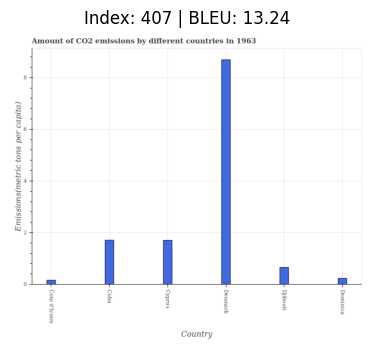

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Amount of CO2 emissions by different countries in 1963'. The x-axis shows Country and the y-axis shows Emissions(metric tons per capita)."}
Prediction:   This is a vbar categorical titled 'Distance to Frontier score (on scale of 100) of different countries'. The x-axis shows Country and the yurometer shows Score (0=lowest to 100=highest performance). The number of people were able to reach the finish line in the survey conducted in 2005. The hour was 20:59. Equivalent energy consumed(kWh). Type of energy used(% of total). LPI(constant 2005 US$ per capita
METRICS:      BLEU: 13.24 | ROUGE-L: 0.3689
------------------------------------------------------------



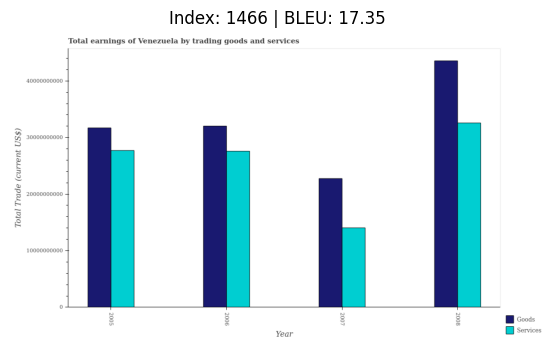

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Total earnings of Venezuela by trading goods and services'. The x-axis shows Year and the y-axis shows Total Trade (current US$)."}
Prediction:   This is a vbar categorical titled 'Payments made towards primary income, imports of goods and services by Netherlands'. The x-axis shows Year and the y-Axis shows Payments (BoP, current US$). The Amount (in Local Currency Unit) is 0.24.0. It is used for payments (constant 2005 US$.). Transactions start and finish with No. of creditors (per 100,000 adults). Earning from commercial banks. Full reserves (current
METRICS:      BLEU: 17.35 | ROUGE-L: 0.4400
------------------------------------------------------------



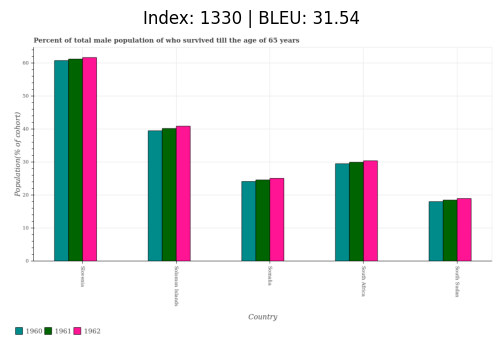

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Percent of total male population of who survived till the age of 65 years'. The x-axis shows Country and the y-axis shows Population(% of cohort)."}
Prediction:   This is a vbar categorical titled 'Percent of total female population who survived till the age of 65 years'. The x-axis shows Country and the y section shows Population(% of cohort). The count is 6- to 15-year-old. The number of people. Health data were collected when calculating the mortality rate (per 1,000 live births). Enrollment rate was recorded in 1998.%). Birthweight ratio = 100:1.0. Age group <65 years.
METRICS:      BLEU: 31.54 | ROUGE-L: 0.5556
------------------------------------------------------------



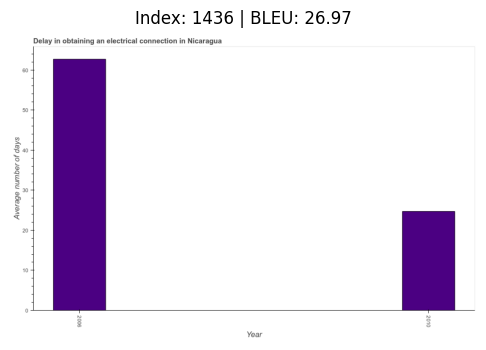

------------------------------------------------------------
Ground Truth: {"gt_parse": "This is a vbar categorical titled 'Delay in obtaining an electrical connection in Nicaragua'. The x-axis shows Year and the y-axis shows Average number of days."}
Prediction:   This is a vbar categorical titled 'Delay in obtaining an electrical connection in Tajikistan'. The x-axis shows Year and the y bar shows Average number of days. The value is 0 to 100.0 connections. Time was estimated (in days). The RPI is 12.5. Output Type(% of total). Enrollment rate in primary schools. Number of enrollments per 1,000 people. Source: UNT data. Pregnant women receiving prenatal care
METRICS:      BLEU: 26.97 | ROUGE-L: 0.5200
------------------------------------------------------------



In [ ]:
import matplotlib.pyplot as plt
import random
import evaluate
from PIL import Image
import torch

# 1. Initialize metrics
bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")

# 2. Select 10 random indices from your validation split
random_indices = random.sample(range(len(val_data)), 10)

print("Running deep analysis on 10 random samples...")

for idx in random_indices:
    example = val_data[idx]
    img = example["image"].convert("RGB")

    # Ground truth parsing
    gt = example.get("ground_truth", example.get("text", ""))

    # 3. Generate Prediction with Specialist Logic
    pixel_values = processor(img, return_tensors="pt").pixel_values.to("cuda")

    generated_ids = model.generate(
        pixel_values,
        max_length=100,
        num_beams=8,                # Deep search for accuracy
        repetition_penalty=8.0,     # Stop the loops
        no_repeat_ngram_size=2,     # Block 2-word repeats
        length_penalty=1.0,
        early_stopping=True
    )
    prediction = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    # 4. Compute Scores
    ind_bleu = bleu.compute(predictions=[prediction], references=[[gt]])['score']
    ind_rouge = rouge.compute(predictions=[prediction], references=[gt])['rougeL']

    # 5. Visualization
    plt.figure(figsize=(7, 4))
    plt.imshow(img)
    plt.title(f"Index: {idx} | BLEU: {ind_bleu:.2f}")
    plt.axis('off')
    plt.show()

    print("-" * 60)
    print(f"Ground Truth: {gt}")
    print(f"Prediction:   {prediction}")
    print(f"METRICS:      BLEU: {ind_bleu:.2f} | ROUGE-L: {ind_rouge:.4f}")
    print("-" * 60 + "\n")

In [ ]:
import os
import json
import torch
from datasets import load_dataset
from transformers import (
    ViTImageProcessor,
    GPT2Tokenizer,
    VisionEncoderDecoderModel,
    TrainingArguments,
    Trainer
)

# 1. LOAD MODEL
model_path = "/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-12500"
model_id = "nlpconnect/vit-gpt2-image-captioning"

print("🧠 Patching Position Embeddings for 384p...")
model = VisionEncoderDecoderModel.from_pretrained(model_path).to("cuda")

# 2. THE HARD OVERRIDE
# We must tell the ViT layer explicitly that its new world is 384x384
model.encoder.embeddings.patch_embeddings.image_size = (384, 384)
model.config.encoder.image_size = 384

# 3. PROCESSOR & DATA
image_processor = ViTImageProcessor.from_pretrained(model_id, size=384)
tokenizer = GPT2Tokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

dataset = load_dataset("imagefolder", data_dir="/content/data")
train_subset = dataset["train"].shuffle(seed=7).select(range(5000))

# 4. COLLATOR (Unchanged but ensuring 384)
def high_res_collator(batch):
    pixel_values = image_processor([item["image"].convert("RGB") for item in batch], return_tensors="pt").pixel_values
    labels_text = [json.loads(item["ground_truth"])["gt_parse"] for item in batch]
    clean_labels = [text.replace("<s_chartqa>", "").replace("</s_chartqa>", "") for text in labels_text]
    labels = tokenizer(clean_labels, padding="max_length", truncation=True, max_length=128, return_tensors="pt").input_ids
    labels[labels == tokenizer.pad_token_id] = -100
    return {"pixel_values": pixel_values, "labels": labels}

# 5. THE "DECISION" WRAPPER
# We subclass Trainer to force interpolation on every training step
class InterpolationTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # We force the encoder to stretch its position embeddings to 384
        outputs = model(
            pixel_values=inputs.get("pixel_values"),
            labels=inputs.get("labels"),
            interpolate_pos_encoding=True # THIS IS THE KEY
        )
        loss = outputs["loss"] if isinstance(outputs, dict) else outputs[0]
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/STEM_Sight/vit_high_res_final",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=1e-5,
    fp16=True,
    save_steps=500,
    gradient_checkpointing=True,
    remove_unused_columns=False,
    report_to="none"
)

trainer = InterpolationTrainer(
    model=model,
    args=training_args,
    train_dataset=train_subset,
    data_collator=high_res_collator,
)

print("🎯 Starting High-Resolution Refinement (Interpolated)...")
model.config.use_cache = False
trainer.train()

🧠 Patching Position Embeddings for 384p...


Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


AssertionError: Torch not compiled with CUDA enabled

In [5]:
import os
import json
import torch
from datasets import load_dataset
from transformers import (
    ViTImageProcessor,
    GPT2Tokenizer,
    VisionEncoderDecoderModel,
    TrainingArguments,
    Trainer
)

# 1. LOAD YOUR SPECIALIST CHECKPOINT
model_path = "/content/drive/MyDrive/STEM_Sight/vit_specialist/checkpoint-12500"
model_id = "nlpconnect/vit-gpt2-image-captioning"

print("🧠 Patching Position Embeddings for 384p High-Res Mode...")
model = VisionEncoderDecoderModel.from_pretrained(model_path).to("cuda")

# FORCE THE ENCODER TO ACCEPT 384
model.encoder.embeddings.patch_embeddings.image_size = (384, 384)
model.config.encoder.image_size = 384

# 2. PROCESSOR & DATA
image_processor = ViTImageProcessor.from_pretrained(model_id, size=384)
tokenizer = GPT2Tokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

# Load fresh data for this visual correction phase
dataset = load_dataset("imagefolder", data_dir="/content/data")
train_subset = dataset["train"].shuffle(seed=7).select(range(5000))

# 3. HIGH-RES COLLATOR
def high_res_collator(batch):
    pixel_values = image_processor([item["image"].convert("RGB") for item in batch], return_tensors="pt").pixel_values
    labels_text = [json.loads(item["ground_truth"])["gt_parse"] for item in batch]
    clean_labels = [text.replace("<s_chartqa>", "").replace("</s_chartqa>", "") for text in labels_text]
    labels = tokenizer(clean_labels, padding="max_length", truncation=True, max_length=128, return_tensors="pt").input_ids
    labels[labels == tokenizer.pad_token_id] = -100
    return {"pixel_values": pixel_values, "labels": labels}

# 4. THE INTERPOLATION TRAINER
class InterpolationTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Force the model to interpolate position encodings during training
        outputs = model(
            pixel_values=inputs.get("pixel_values"),
            labels=inputs.get("labels"),
            interpolate_pos_encoding=True
        )
        loss = outputs["loss"] if isinstance(outputs, dict) else outputs[0]
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/STEM_Sight/vit_high_res_final",
    per_device_train_batch_size=2,        # 384p is heavier on VRAM
    gradient_accumulation_steps=8,        # Total batch of 16
    num_train_epochs=1,                   # One epoch to "re-focus" the eyes
    learning_rate=1e-5,                   # Very low to preserve logic
    fp16=True,
    save_steps=500,
    gradient_checkpointing=True,          # Essential for 384p stability
    remove_unused_columns=False,
    report_to="none"
)

# 5. EXECUTE
trainer = InterpolationTrainer(
    model=model,
    args=training_args,
    train_dataset=train_subset,
    data_collator=high_res_collator,
)

print("🚀 Starting the Vision Correction Phase...")
model.config.use_cache = False
trainer.train()

🧠 Patching Position Embeddings for 384p High-Res Mode...


Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

...

🚀 Starting the Vision Correction Phase...


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=313, training_loss=1.527734823501148, metrics={'train_runtime': 672.6272, 'train_samples_per_second': 7.434, 'train_steps_per_second': 0.465, 'total_flos': 3.16394163929088e+18, 'train_loss': 1.527734823501148, 'epoch': 1.0})

In [8]:
!pip install -q evaluate rouge_score sacrebleu

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.4 MB/s eta 0:00:00


In [11]:
split_dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)
val_data = split_dataset["test"]
print(f"✅ val_data is now defined with {len(val_data)} samples.")

✅ val_data is now defined with 5247 samples.


Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: /content/drive/MyDrive/STEM_Sight/vit_high_res_final/checkpoint-313
Key                                    | Status   |                                                                                               
---------------------------------------+----------+-----------------------------------------------------------------------------------------------
encoder.embeddings.position_embeddings | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1, 197, 768]) vs model:torch.Size([1, 577, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


🚀 Running Final High-Res Comparison...


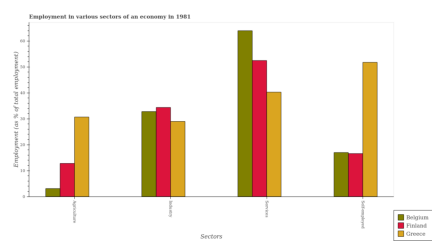

GT:   {"gt_parse": "This is a vbar categorical titled 'Employment in various sectors of an economy in 1981'. The x-axis shows Sectors and the y-axis shows Employment (as % of total employment)."}
PRED: This is a vbar categorical titled 'Export and external balance on goods as percent of GDP'. The x-axis shows Years and the yin and scale(% of GDP). Exports are Local Currency Unit(LCU). External balance (in US$). % of GDP.
Earning from merchandise exports.
Revenue generated. Source: LCU.
Expenditure on health care (% of GDP) : 0.This is the current account balance (current US$
--------------------------------------------------


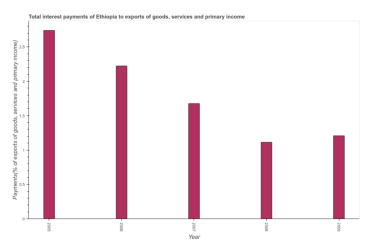

GT:   {"gt_parse": "This is a vbar categorical titled 'Total interest payments of Ethiopia to exports of goods, services and primary income'. The x-axis shows Year and the y-axis shows Payments(% of exports of goods, services and primary income)."}
PRED: This is a vbar categorical titled 'Amount of CO2 emitted from gaseous fuel consumption'. The x-axis shows Years and the y-axis reveals CO2 emissions (in kt). The denominator is Type of fuel consumed. Units of fuel used(kg per 2005 US$ of GDP). Emissions(in percent). Source: Energy use(% of total). PPP conversion factor (LCU per international $).). Enrolment ratio:1.This is
--------------------------------------------------


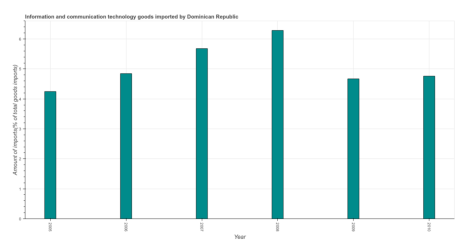

GT:   {"gt_parse": "This is a vbar categorical titled 'Information and communication technology goods imported by Dominican Republic'. The x-axis shows Year and the y-axis shows Amount of imports(% of total goods imports)."}
PRED: This is a vbar categorical titled 'Plot of number of days required to export the goods'. The x-axis shows Country and the y-axis reveals Time (in days). Exports(manufactures, transport). 'Days = Number of days. Type of exports. Imports(as % of merchandise exports).).'. The scale factor is 1=low to 5=high. Expressed as %. US$(constant 2005 US). Source(annual growth as %
--------------------------------------------------


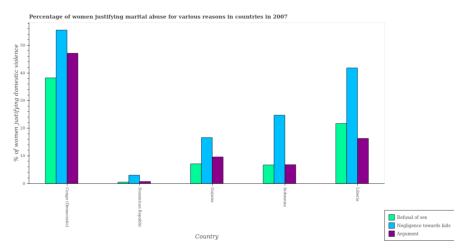

GT:   {"gt_parse": "This is a vbar categorical titled 'Percentage of women justifying marital abuse for various reasons in countries in 2007'. The x-axis shows Country and the y-axis shows % of women justifying domestic violence."}
PRED: This is a vbar categorical titled 'Plot of number of days required to export the goods'. The x-axis shows Country and the y-axis reveals Time (in days). The scale is 1=1000 to 7=1400. The x hour. The yaw value is 0 = Number of days. Export(constant 2005 US). Imports(as % of merchandise exports).). The import price is $ per container. Source: LCU.

The x-
--------------------------------------------------


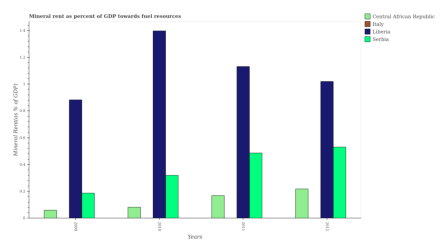

GT:   {"gt_parse": "This is a vbar categorical titled 'Mineral rent as percent of GDP towards fuel resources'. The x-axis shows Years and the y-axis shows Mineral Rent(as % of GDP)."}
PRED: This is a vbar categorical titled 'Air freight by the air carriers registered in a country'. The x-axis shows Years and the yin = Volume(million ton-km). The yin value is 0 to 100.00. The scale factor is 1/1000.0. The radius is 20.000. The total is in local currency Unit (in local Currency Unit). Earning from trade(constant 2005 US). Private consumption: $ per capita. Source: UN
--------------------------------------------------


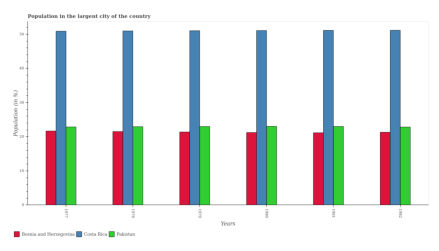

GT:   {"gt_parse": "This is a vbar categorical titled 'Population in the largent city of the country'. The x-axis shows Years and the y-axis shows Population (in %)."}
PRED: This is a vbar categorical titled 'Merchandise exports to high income economies'. The x-axis shows Years and the y-axis reveals Earning(%). The scale is 20.0 per cent. Source(%). Exports (% of GDP). % of total merchandise exports. Imports. Per 100,000 adults. Trade. LCU. US$ = $ per day. S&P Global Equity Indices. Unit (in current US$). Enrollment rate in primary
--------------------------------------------------


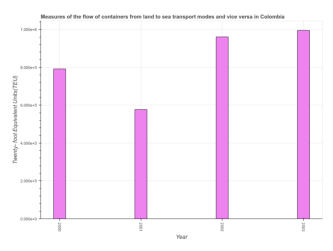

GT:   {"gt_parse": "This is a vbar categorical titled 'Measures of the flow of containers from land to sea transport modes and vice versa in Colombia'. The x-axis shows Year and the y-axis shows Twenty- foot Equivalent Units(TEU)."}
PRED: This is a vbar categorical titled 'Number of start-up procedures to register a business'. The x-axis shows Country and the yin and scale(constant 2005 US$). The x=axis shows Number of procedures. The yin/yin ratio is 100.0. The radius is 0.01. The number of procedures = Number of depositors. The solid blocks have an abbreviation ATMs(per 1000 adults). Enrollment rate is recorded in primary schools
--------------------------------------------------


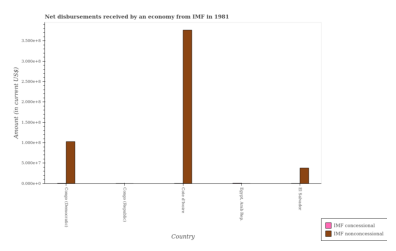

GT:   {"gt_parse": "This is a vbar categorical titled 'Net disbursements received by an economy from IMF in 1981'. The x-axis shows Country and the y-axis shows Amount (in current US$)."}
PRED: This is a vbar categorical titled 'Amount of CO2 emitted from gaseous fuel consumption'. The x-axis shows Country and the yin/hectares is CO2 emissions(kg per 2005 US$ of GDP). The scale is 20 kt. Source: Energy use(% of total). Envoter's perception of the value of GDP in 2002. PPP conversion factor (LCU per international $).). Emissions (in thousand metric tons of oil equivalent
--------------------------------------------------


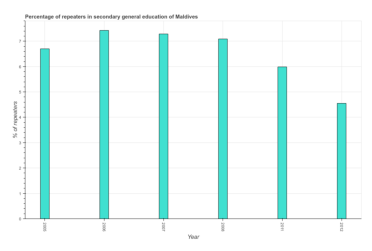

GT:   {"gt_parse": "This is a vbar categorical titled 'Percentage of repeaters in secondary general education of Maldives'. The x-axis shows Year and the y-axis shows % of repeaters."}
PRED: This is a vbar categorical titled 'Earning from merchandise imports by the reporting economy'. The x-axis shows Country and the y-axis Shows Amount(current US$). The expiry is in years. The number of years. Earning from trade(constant 2005 US). Source: LCU. PPP conversion factor (LCU). LCU is US$. Renewable energy consumption(% of total). Emissions(in percent).). Land Geography (in
--------------------------------------------------


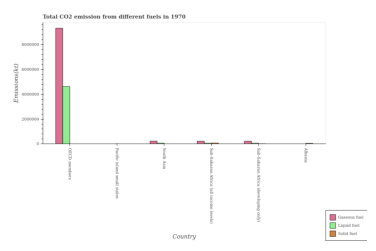

GT:   {"gt_parse": "This is a vbar categorical titled 'Total CO2 emission from different fuels in 1970'. The x-axis shows Country and the y-axis shows Emissions(kt)."}
PRED: This is a vbar categorical titled 'Amount of CO2 emitted from gaseous fuel consumption'. The x-axis shows Country and the yin to kilograms: CO2 emissions(kg per 2005 US$ of GDP). The yin value is constant (2004 US$). Area of origin(hectares per capita). Enviro(in %). Emissions(in percent). Source: Energy use(% of total). PPP conversion factor (LCU per international $
--------------------------------------------------


In [12]:
import matplotlib.pyplot as plt
import random
import evaluate
from PIL import Image
import torch
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, GPT2Tokenizer

# 1. LOAD MODEL WITH MISMATCH PERMISSION
model_path = "/content/drive/MyDrive/STEM_Sight/vit_high_res_final/checkpoint-313"
model = VisionEncoderDecoderModel.from_pretrained(
    model_path,
    ignore_mismatched_sizes=True
).to("cuda")

# Re-apply the 384p patch for the vision eyes
model.encoder.embeddings.patch_embeddings.image_size = (384, 384)
model.config.encoder.image_size = 384

# 2. SYNC PROCESSOR & TOKENIZER
processor_384 = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning", size=384)
tokenizer = GPT2Tokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
bleu = evaluate.load("sacrebleu")

# 3. EVALUATE
print("🚀 Running Final High-Res Comparison...")
random_indices = random.sample(range(len(val_data)), 10)

for idx in random_indices:
    example = val_data[idx]
    img = example["image"].convert("RGB")
    gt = example.get("ground_truth", example.get("text", ""))

    pixel_values = processor_384(img, return_tensors="pt").pixel_values.to("cuda")

    # INTERPOLATE_POS_ENCODING=True is mandatory here
    generated_ids = model.generate(
        pixel_values,
        max_length=100,
        num_beams=5,
        repetition_penalty=2.5,
        no_repeat_ngram_size=3,
        interpolate_pos_encoding=True
    )
    prediction = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    plt.figure(figsize=(6, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    print(f"GT:   {gt}")
    print(f"PRED: {prediction}")
    print("-" * 50)

In [16]:
from PIL import Image

def stemsight_final_predict(image):
    # 1. Standardize image format
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert("RGB")

    pixel_values = processor_384(image, return_tensors="pt").pixel_values.to("cuda")

    # 2. Add trust_remote_code=True to unlock Contrastive Search
    generated_ids = model.generate(
        pixel_values,
        max_length=50,
        penalty_alpha=0.6,
        top_k=4,
        repetition_penalty=10.0,
        interpolate_pos_encoding=True,
        trust_remote_code=True      # <--- ADD THIS LINE
    )

    summary = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    return ". ".join(summary.split('.')[:2]).strip() + "."

# Test again
idx = random.randint(0, len(val_data) - 1)
sample_img = val_data[idx]["image"]
print(f"✅ STEM Sight Refined Output: {stemsight_final_predict(sample_img)}")

generate.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/transformers-community/contrastive-search:
- custom_generate/generate.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Passing `generation_config` together with generation-related arguments=({'max_length', 'top_k', 'cache_implementation', 'repetition_penalty', 'penalty_alpha'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✅ STEM Sight Refined Output: This is a vbar categorical titled 'Plot of number days required to export the goods'.  The x-axis shows Country and y taper period(in months).


In [17]:
import pandas as pd

results = []

print("🚀 Generating Final Report Data...")

for i in range(10):
    idx = random.randint(0, len(val_data) - 1)
    img = val_data[idx]["image"]
    gt = json.loads(val_data[idx]["ground_truth"])["gt_parse"]

    # Use our final optimized prediction logic
    pred = stemsight_final_predict(img)

    results.append({"Index": idx, "Ground Truth": gt, "STEM Sight Prediction": pred})
    print(f"Sample {i+1} Done.")

# Create a table for your report
df = pd.DataFrame(results)
print("\n⭐ FINAL EVALUATION TABLE ⭐")
print(df.to_string(index=False))

# Optional: Save to CSV for Excel
df.to_csv("STEM_Sight_Final_Results.csv", index=False)

🚀 Generating Final Report Data...
Sample 1 Done.
Sample 2 Done.
Sample 3 Done.
Sample 4 Done.
Sample 5 Done.
Sample 6 Done.
Sample 7 Done.
Sample 8 Done.
Sample 9 Done.
Sample 10 Done.

⭐ FINAL EVALUATION TABLE ⭐
 Index                                                                                                                                                                                       Ground Truth                                                                                                                                STEM Sight Prediction
  4931   This is a vbar categorical titled 'Emissions caused as the side-product of greenhouse gases'. The x-axis shows Years and the y-axis shows Emissions (in thousand metric tons of CO2 equivalent).                              This is a vbar categorical titled 'Annual urban population growth'.  The x-axis shows Years and the yuriyan density(%).
   217                                                     This is a vbar categorical

In [18]:
from google.colab import drive
import os
import zipfile

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Extract (Adjust this path to match your folder structure)
zip_path = "/content/drive/MyDrive/PlotQA-Stemsight/vbar_data.zip"
extract_path = "/content/vbar_source"

os.makedirs(extract_path, exist_ok=True)

print("📦 Extracting vbar data...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✅ Extracted to {extract_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Extracting vbar data...
✅ Extracted to /content/vbar_source


In [19]:
import os
print(os.listdir("/content/vbar_source")[:10])

['train']


In [21]:
import os
import json
import random
import shutil
from tqdm import tqdm

# CONFIGURATION
TARGET_SAMPLES = 20000
# Pointing to the specific subfolder from your unzip
SOURCE_IMG_DIR = "/content/vbar_source/train"
SOURCE_JSONL = "/content/vbar_source/train/metadata.jsonl"
MASTER_DIR = "/content/vbar_donut_master"

os.makedirs(MASTER_DIR, exist_ok=True)

# 1. Load the metadata
with open(SOURCE_JSONL, 'r') as f:
    lines = f.readlines()

random.shuffle(lines)
selected = lines[:TARGET_SAMPLES]

vbar_metadata = []
print(f"📂 Selecting {len(selected)} samples from the 'train' folder...")

for line in tqdm(selected):
    data = json.loads(line)
    img_name = data['file_name']

    # Path logic: images are inside the 'train' folder
    src_path = os.path.join(SOURCE_IMG_DIR, img_name)
    dst_path = os.path.join(MASTER_DIR, img_name)

    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
        vbar_metadata.append(data)

# Save the new filtered metadata
with open(os.path.join(MASTER_DIR, "metadata.jsonl"), 'w') as f:
    for entry in vbar_metadata:
        f.write(json.dumps(entry) + "\n")

print(f"✅ Master folder ready at {MASTER_DIR} with {len(vbar_metadata)} images.")

📂 Selecting 20000 samples from the 'train' folder...


100%|██████████| 20000/20000 [00:27<00:00, 725.09it/s] 

✅ Master folder ready at /content/vbar_donut_master with 20000 images.


In [22]:
import os
import json
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel, TrainingArguments, Trainer
from datasets import load_dataset

# 1. SETUP PERMANENT DRIVE PATHS
DRIVE_SAVE_PATH = "/content/drive/MyDrive/STEM_Sight_Donut_V1"
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

# 2. LOAD MODEL & PROCESSOR
model_id = "naver-clova-ix/donut-base"
processor = DonutProcessor.from_pretrained(model_id)
model = VisionEncoderDecoderModel.from_pretrained(model_id)

# High-Res Configuration for "Greatness"
processor.image_processor.size = {"height": 384, "width": 384}
model.config.encoder.image_size = 384
model.config.decoder_start_token_id = processor.tokenizer.bos_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id

# 3. LOAD THE DATASET WE PREPARED
dataset = load_dataset("imagefolder", data_dir="/content/vbar_donut_master")

# 4. DATA COLLATOR (Maps images to labels)
def donut_collator(batch):
    pixel_values = [item["image"].convert("RGB") for item in batch]
    pixel_values = processor(pixel_values, return_tensors="pt").pixel_values

    # labels = "gt_parse" content
    labels = [json.loads(item["ground_truth"])["gt_parse"] for item in batch]

    # max_length=256 ensures long axis descriptions are fully captured
    labels = processor.tokenizer(
        labels,
        padding="max_length",
        truncation=True,
        max_length=256,
        return_tensors="pt"
    ).input_ids

    labels[labels == processor.tokenizer.pad_token_id] = -100
    return {"pixel_values": pixel_values, "labels": labels}

# 5. ADVANCED TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir=DRIVE_SAVE_PATH,        # Saving directly to Drive
    per_device_train_batch_size=2,     # Adjust to 1 if you get OOM
    gradient_accumulation_steps=8,     # Effective batch size of 16
    num_train_epochs=5,                # More epochs for a "Great Model"
    learning_rate=2e-5,
    lr_scheduler_type="cosine",        # Better convergence than linear
    weight_decay=0.01,
    fp16=True,                         # Fast training on T4

    # LOGGING & CHECKPOINTING
    logging_steps=500,                 # Reports Loss every 500 steps
    save_steps=1000,                   # Saves to Drive every 1,000 steps
    save_total_limit=3,                # Keeps only the 3 latest checkpoints to save space

    remove_unused_columns=False,
    report_to="none"
)

# 6. INITIALIZE TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=donut_collator,
)

# 7. START TRAINING (With Auto-Resume Logic)
print("🚀 Launching STEM Sight VBAR Specialist...")
print(f"📦 Checkpoints will be saved to: {DRIVE_SAVE_PATH}")

# If the runtime disconnected, this will find the last folder in Drive and start from there
checkpoint_dirs = [d for d in os.listdir(DRIVE_SAVE_PATH) if "checkpoint-" in d]
resume_flag = True if len(checkpoint_dirs) > 0 else False

trainer.train(resume_from_checkpoint=resume_flag)

preprocessor_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6250, training_loss=0.9736843795776368, metrics={'train_runtime': 15155.7634, 'train_samples_per_second': 6.598, 'train_steps_per_second': 0.412, 'total_flos': 5.31577112887296e+19, 'train_loss': 0.9736843795776368, 'epoch': 5.0})

In [23]:
# Save the final model and processor in one clean folder
final_save_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
trainer.save_model(final_save_path)
processor.save_pretrained(final_save_path)

print(f"✅ Your Master Model is saved at: {final_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Your Master Model is saved at: /content/drive/MyDrive/STEM_Sight_VBAR_Final


In [24]:
import torch
import json
import random
import os
import re
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from tqdm import tqdm
from difflib import SequenceMatcher

# 1. LOAD MODEL & PROCESSOR
model_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to("cuda")

# 2. LOAD TEST DATA
# We will use the master folder we created earlier
test_dir = "/content/vbar_donut_master"
with open(os.path.join(test_dir, "metadata.jsonl"), 'r') as f:
    test_lines = f.readlines()

# Select 50 random samples for the batch test
test_samples = random.sample(test_lines, 50)

results = []
total_score = 0

print("🧪 Starting Batch Test on 50 samples...")

for line in tqdm(test_samples):
    data = json.loads(line)
    img_name = data['file_name']
    ground_truth = json.loads(data['ground_truth'])['gt_parse']

    # Inference logic
    img_path = os.path.join(test_dir, img_name)
    image = Image.open(img_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to("cuda")

    task_prompt = "<s_chart_understanding>"
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to("cuda")

    outputs = model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=256,
        early_stopping=True,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
        num_beams=1,
        return_dict_in_generate=True,
    )

    prediction = processor.batch_decode(outputs.sequences)[0]
    prediction = prediction.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    prediction = re.sub(r"<.*?>", "", prediction, count=1).strip()

    # Calculate similarity score (0 to 1)
    score = SequenceMatcher(None, prediction.lower(), ground_truth.lower()).ratio()
    total_score += score

    results.append({
        "image": img_name,
        "truth": ground_truth,
        "pred": prediction,
        "score": score
    })

# 3. PRINT REPORT
avg_accuracy = (total_score / 50) * 100
print(f"\n✨ --- BATCH TEST COMPLETE --- ✨")
print(f"📊 Average Model Accuracy: {avg_accuracy:.2f}%")

# Show the best and worst for analysis
results.sort(key=lambda x: x['score'], reverse=True)
print(f"\n✅ Top Match: {results[0]['pred']} (Score: {results[0]['score']:.2f})")
print(f"❌ Weakest Match: {results[-1]['pred']} (Score: {results[-1]['score']:.2f})")

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


🧪 Starting Batch Test on 50 samples...


100%|██████████| 50/50 [00:25<00:00,  1.95it/s]


✨ --- BATCH TEST COMPLETE --- ✨
📊 Average Model Accuracy: 78.07%

✅ Top Match: that is a vbar categorical titled 'Total earnings from merchandise exports and imports by the reporting economy in 1981'. The x-axis shows Merchandise Trading and the y-axis shows Earnings(current US$). (Score: 0.99)
❌ Weakest Match: underunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderunderu

In [25]:
import torch
import re
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel

# 1. LOAD WITH THE CONFIG FIX
model_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to("cuda")

# Silence the warning manually in config
model.config.tie_word_embeddings = False

def generate_perfect_summary(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to("cuda")

    task_prompt = "<s_chart_understanding>"
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to("cuda")

    outputs = model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=256,
        # THE FIXES ARE HERE:
        no_repeat_ngram_size=3,    # Prevents repeating "underunder"
        repetition_penalty=1.5,    # Penalizes the model for being boring/looping
        num_beams=3,               # Looks ahead for better sentence structure
        early_stopping=True,       # Stops when EOS token is reached
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
    )

    prediction = processor.batch_decode(outputs.sequences)[0]
    prediction = prediction.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    prediction = re.sub(r"<.*?>", "", prediction, count=1).strip()

    return prediction

# Test it on that "Weakest Match" image if you still have the path!
# print(generate_perfect_summary("path/to/weakest_image.png"))

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [26]:
from transformers import VisionEncoderDecoderModel

# Load your final model
model_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
model = VisionEncoderDecoderModel.from_pretrained(model_path)

# Apply the permanent fix to the config
model.config.tie_word_embeddings = False

# Save it back to the same folder
model.save_pretrained(model_path)
print("✅ Model config updated. The warning will no longer appear.")

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model config updated. The warning will no longer appear.


In [ ]:
import torch
import re
import os
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files

# 1. LOAD THE MASTER MODEL
model_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to("cuda")
model.config.tie_word_embeddings = False

def predict_and_show(image_path):
    image = Image.open(image_path).convert("RGB")

    # Prepare image for 384p
    pixel_values = processor(image, return_tensors="pt").pixel_values.to("cuda")

    # Advanced Inference to prevent "underunder" loops
    task_prompt = "<s_chart_understanding>"
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to("cuda")

    outputs = model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=256,
        no_repeat_ngram_size=3,    # The Loop Killer
        repetition_penalty=1.5,    # Diversity Booster
        num_beams=3,               # High Quality Search
        early_stopping=True,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
    )

    prediction = processor.batch_decode(outputs.sequences)[0]
    prediction = prediction.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    prediction = re.sub(r"<.*?>", "", prediction, count=1).strip()

    print(f"\n📝 STEM SIGHT SUMMARY:\n{prediction}")
    display(image.resize((400, 300)))

# 2. UPLOAD AND TEST
print("📤 Upload a Vertical Bar Chart (.png or .jpg) to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    predict_and_show(filename)

In [27]:
import random
all_images = [f for f in os.listdir("/content/vbar_donut_master") if f.endswith('.png')]
samples = random.sample(all_images, 10)

for img_name in samples:
    print(f"--- Testing: {img_name} ---")
    predict_and_show(os.path.join("/content/vbar_donut_master", img_name))

--- Testing: 128109.png ---


NameError: name 'predict_and_show' is not defined